# Liver Disease — Model Evaluation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix


In [2]:
model = joblib.load("../../models/liver_disease_model.pkl")
X_test = pd.read_csv("../../data/processed/liver_disease_X_test.csv")
y_test = pd.read_csv("../../data/processed/liver_disease_y_test.csv").squeeze()


In [3]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["No Disease", "Liver Disease"]))


               precision    recall  f1-score   support

   No Disease       0.67      0.18      0.28        34
Liver Disease       0.74      0.96      0.84        83

     accuracy                           0.74       117
    macro avg       0.70      0.57      0.56       117
 weighted avg       0.72      0.74      0.68       117



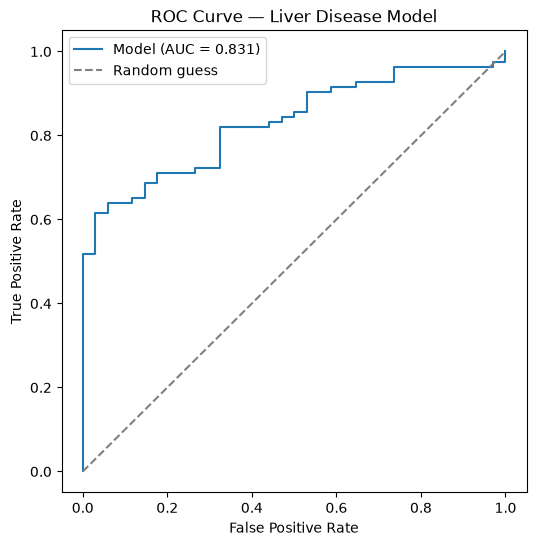

In [4]:
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Model (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Liver Disease Model")
plt.legend()
plt.savefig("../../reports/figures/liver_disease/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()


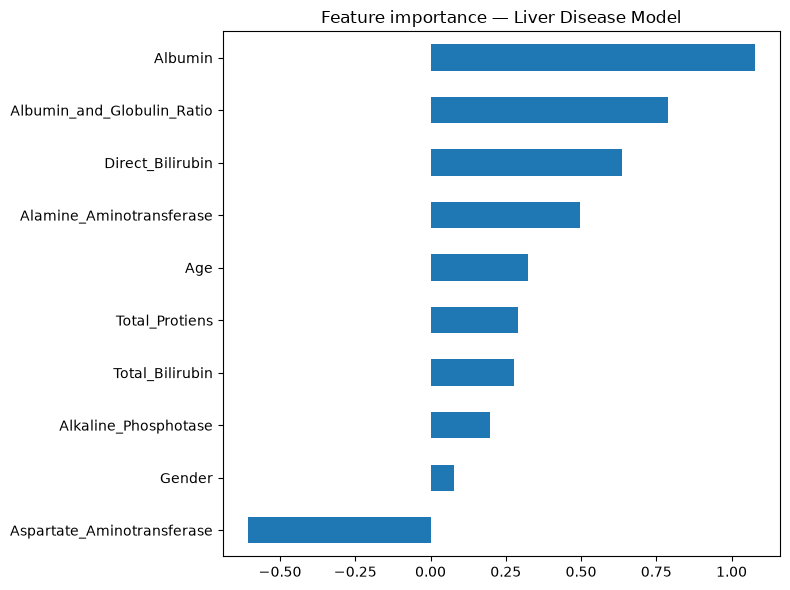

In [5]:
if hasattr(model, "feature_importances_"):
    importances = pd.Series(model.feature_importances_, index=X_test.columns)
elif hasattr(model, "coef_"):
    importances = pd.Series(model.coef_[0], index=X_test.columns)
else:
    importances = None

if importances is not None:
    importances = importances.sort_values(ascending=True)
    plt.figure(figsize=(8, 6))
    importances.plot(kind="barh")
    plt.title("Feature importance — Liver Disease Model")
    plt.tight_layout()
    plt.savefig("../../reports/figures/liver_disease/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()


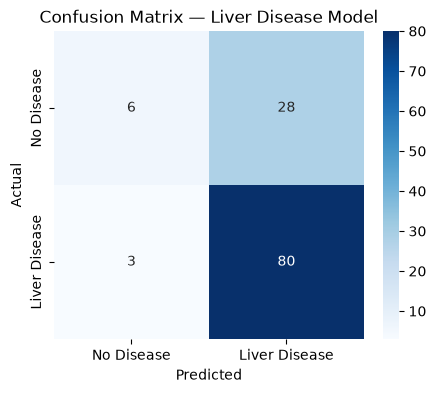

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Liver Disease"],
            yticklabels=["No Disease", "Liver Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Liver Disease Model")
plt.savefig("../../reports/figures/liver_disease/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## All 5 disease pipelines complete!
You should now have 5 trained models sitting in `models/`:
- diabetes_model.pkl
- heart_disease_model.pkl
- ckd_model.pkl
- hypertension_model.pkl
- liver_disease_model.pkl

Plus a matching `_scaler.pkl` for each one.

## Next step
Move to the `webapp/` folder to build the Flask website:
auth first, then the unified form, then the prediction
route that loads all 5 models.